In [1]:
import sys
import os
src_dir = "../../src"
if src_dir not in sys.path:
    sys.path.append(src_dir)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils.error_report import get_error_from_list
from data_loader import DataLoader
from configs.configs import MeasurementDataEnum, SetupEnum, ErrorEnum, FilterEnum, NoiseTypeEnum
from kalman_filters.extended_kalman_filter import ExtendedKalmanFilter
from kalman_filters.unscented_kalman_filter import UnscentedKalmanFilter
from kalman_filters.ensemble_kalman_filter import EnsembleKalmanFilter
from kalman_filters.particle_filter import ParticleFilter, ResamplingAlgorithms
from kalman_filters.cubature_kalman_filter import CubatureKalmanFilter


%matplotlib inline
np.random.seed(777)

# Load raw data 0033 (sequence number 09)

Data size: 1591
Shape:
GPS: (1591, 3)
VO: (1591, 3)
IMU: (1591, 6)
INS angle: (1591, 3)
INS velocity: (1591, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Data sampling is set to normal mode.


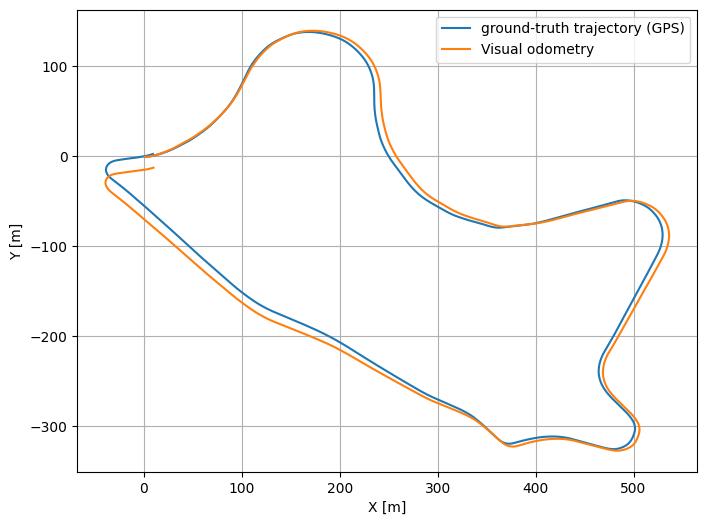

In [2]:
root_path = "../../"
file_export_path = os.path.join(root_path, "exports/_sequences/09")
kitti_root_dir = os.path.join(root_path, "data")
vo_root_dir = os.path.join(root_path, "vo_estimates")
noise_vector_dir = os.path.join(root_path, "exports/_noise_optimizations/noise_vectors")
kitti_date = '2011_09_30'
kitti_drive = '0033'
noise_type = NoiseTypeEnum.CURRENT

data = DataLoader(sequence_nr=kitti_drive, 
                  kitti_root_dir=kitti_root_dir, 
                  vo_root_dir=vo_root_dir,
                  noise_vector_dir=noise_vector_dir,
                  vo_dropout_ratio=0.0, 
                  gps_dropout_ratio=0.0)

## Display data with noise

### VO trajectory with noise

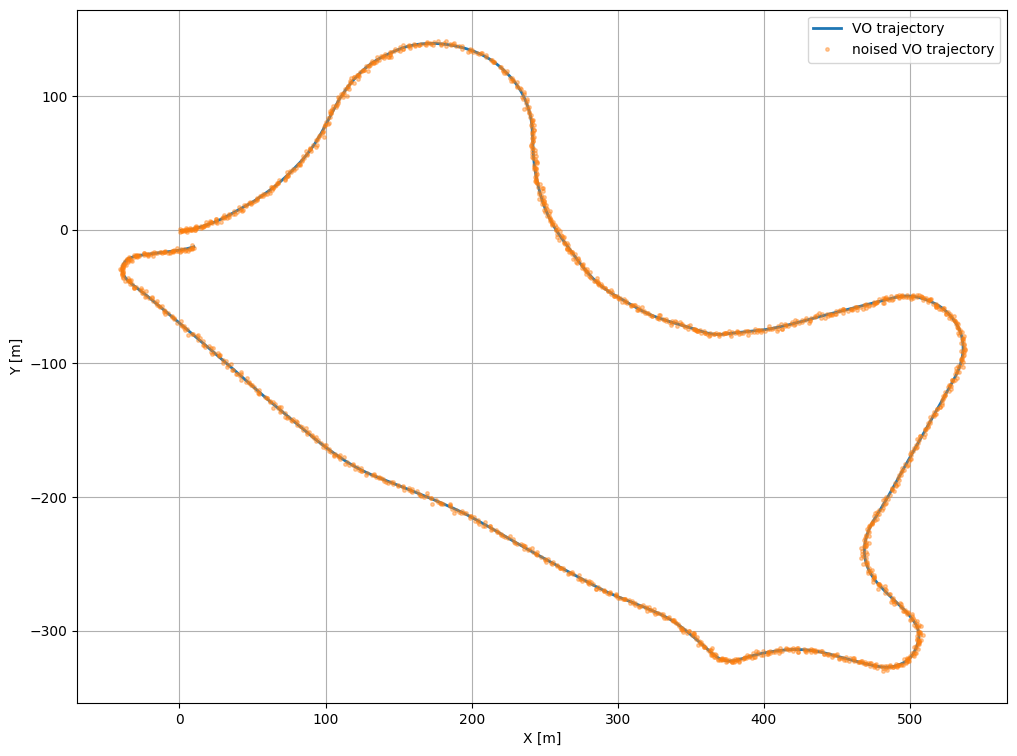

In [3]:
data.show_vo_with_noise()

### Linear acceleration with noise

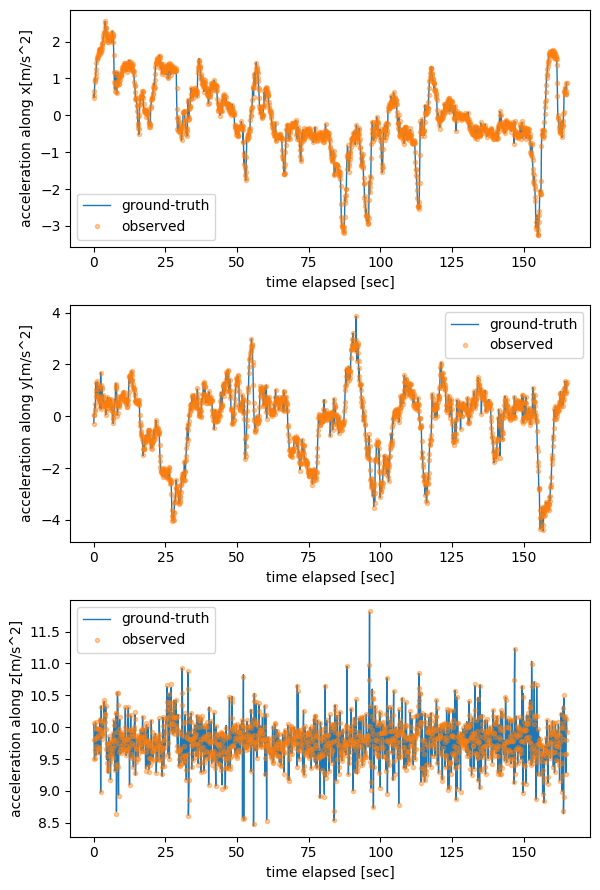

In [4]:
data.show_linear_acceleration_with_noise()

### Angular velocity with noise

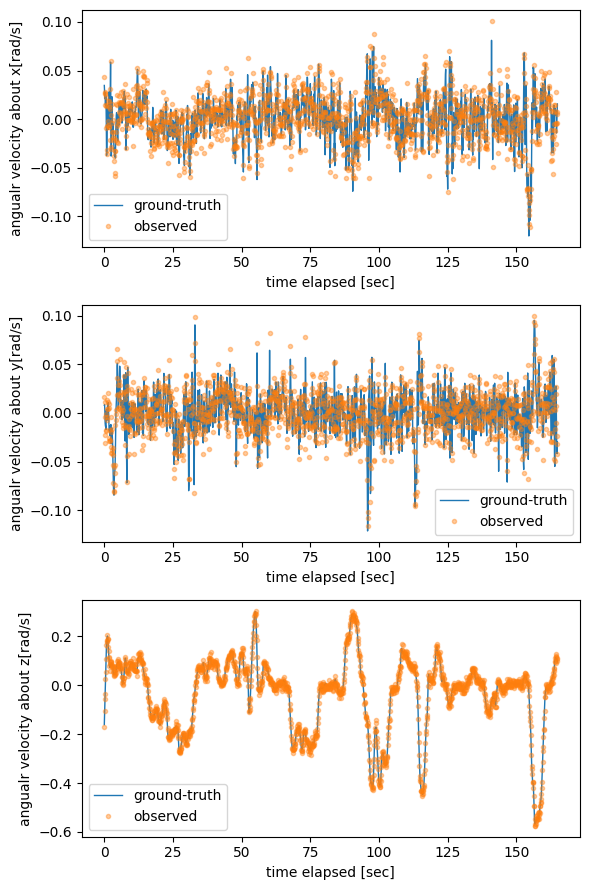

In [5]:
data.show_angular_velocity_with_noise()

### Linear velocity with noise

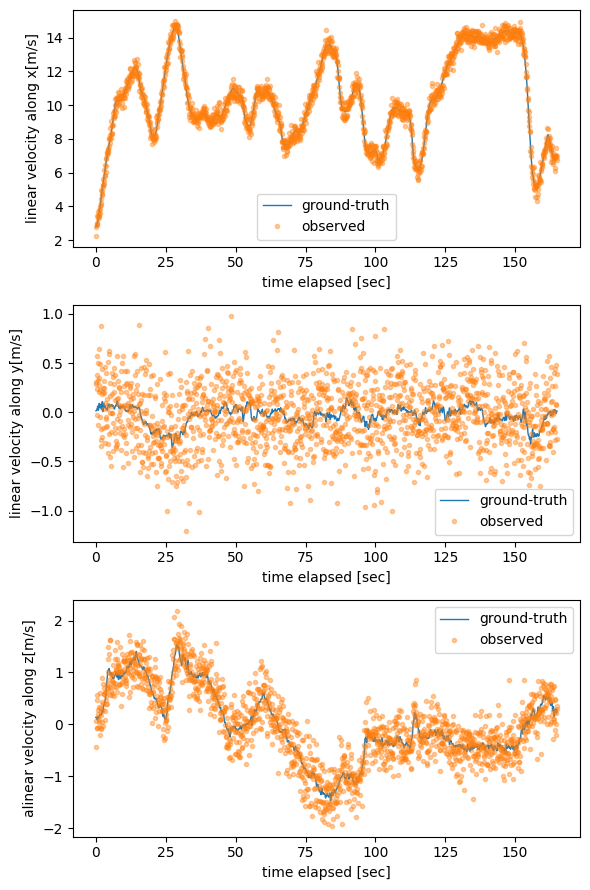

In [6]:
data.show_linear_velocity_with_noise()

# Applying filters

----

In [7]:
results_header = pd.MultiIndex.from_product([['Setup1 (IMU, VO)','Setup2(IMU, VO+GPS)', 'Setup3(INS, VO+INS)'],
                                             ['EKF', 'UKF', 'PF', 'EnKF', 'CKF']],
                                            names=['Setups','Filter types'])
df_dropout_indices = ['No dropout', '10% drop', '20% drop', '30% drop', '40% drop']

def get_error_dataframe(error_0, error_10, error_20, error_30, error_40):
    mae_0 = get_error_from_list(error_0, e_type=ErrorEnum.MAE)
    mae_10 = get_error_from_list(error_10, e_type=ErrorEnum.MAE)
    mae_20 = get_error_from_list(error_20, e_type=ErrorEnum.MAE)
    mae_30 = get_error_from_list(error_30, e_type=ErrorEnum.MAE)
    mae_40 = get_error_from_list(error_40, e_type=ErrorEnum.MAE)

    rmse_0 = get_error_from_list(error_0, e_type=ErrorEnum.RMSE)
    rmse_10 = get_error_from_list(error_10, e_type=ErrorEnum.RMSE)
    rmse_20 = get_error_from_list(error_20, e_type=ErrorEnum.RMSE)
    rmse_30 = get_error_from_list(error_30, e_type=ErrorEnum.RMSE)
    rmse_40 = get_error_from_list(error_40, e_type=ErrorEnum.RMSE)
    
    max_0 = get_error_from_list(error_0, e_type=ErrorEnum.MAX)
    max_10 = get_error_from_list(error_10, e_type=ErrorEnum.MAX)
    max_20 = get_error_from_list(error_20, e_type=ErrorEnum.MAX)
    max_30 = get_error_from_list(error_30, e_type=ErrorEnum.MAX)
    max_40 = get_error_from_list(error_40, e_type=ErrorEnum.MAX)
    
    mae_error = [mae_0, mae_10, mae_20, mae_30, mae_40]
    rmse_error = [rmse_0, rmse_10, rmse_20, rmse_30, rmse_40]
    max_error = [max_0, max_10, max_20, max_30, max_40]
    
    mae_df = pd.DataFrame(np.array(mae_error), 
                            index=df_dropout_indices, 
                            columns=results_header)
    rmse_df = pd.DataFrame(np.array(rmse_error), 
                            index=df_dropout_indices, 
                            columns=results_header)
    max_df = pd.DataFrame(np.array(max_error), 
                            index=df_dropout_indices, 
                            columns=results_header)
    
    return mae_df, rmse_df, max_df



In [8]:
errors_0 = []
errors_10 = []
errors_20 = []
errors_30 = []
errors_40 = []

# No measurement data drop

In [9]:
data.change_dropout_ratio(vo_dropout_ratio=0.0, gps_dropout_ratio=0.0)

In [10]:
alpha_setup1_0 = 1.0
beta_setup1_0 = 6.0
kappa_setup1_0 = 0.0

alpha_setup2_0 = 0.6
beta_setup2_0 = 0.0
kappa_setup2_0 = -7.0

alpha_setup3_0 = 0.0001
beta_setup3_0 = 4.0
kappa_setup3_0 = 0.0

n_samples_setup1_0 = 256
resampling_algorithm_setup1_0 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup2_0 = 256
resampling_algorithm_setup2_0 = ResamplingAlgorithms.STRATIFIED
n_samples_setup3_0 = 256
resampling_algorithm_setup3_0 = ResamplingAlgorithms.MULTINOMIAL

n_ensemble_setup1_0 = 32
n_ensemble_setup2_0 = 256
n_ensemble_setup3_0 = 256

## Setup1

In [11]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_0 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_0 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_0, 
  beta=beta_setup1_0, 
  kappa=kappa_setup1_0,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_0 = ParticleFilter(
  N=n_samples_setup1_0, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_0
)
pf1_0.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_0 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_0, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_0 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

In [12]:
error_ekf1_0 = ekf1_0.run(data=data, debug_mode=True)
error_ukf1_0 = ukf1_0.run(data=data, debug_mode=True)
error_pf1_0 = pf1_0.run(data=data, debug_mode=True)
error_enkf1_0 = enkf1_0.run(data=data, debug_mode=True)
error_ckf1_0 = ckf1_0.run(data=data, debug_mode=True)


errors_0.append(error_ekf1_0)
errors_0.append(error_ukf1_0)
errors_0.append(error_pf1_0)
errors_0.append(error_enkf1_0)
errors_0.append(error_ckf1_0)

[EKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 6808.58it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 4.015, <ErrorEnum.RMSE: 2>: 5.699, <ErrorEnum.MAX: 3>: 18.331}
[UKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 3321.51it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 3.87, <ErrorEnum.RMSE: 2>: 5.399, <ErrorEnum.MAX: 3>: 16.053}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 4.28, <ErrorEnum.RMSE: 2>: 8.104, <ErrorEnum.MAX: 3>: 120.751}
[EnKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 2693.69it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 4.111, <ErrorEnum.RMSE: 2>: 5.675, <ErrorEnum.MAX: 3>: 18.482}
[CKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 3503.10it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 3.909, <ErrorEnum.RMSE: 2>: 5.489, <ErrorEnum.MAX: 3>: 16.347}


## Setup2

In [13]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_0 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_0 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_0, 
    beta=beta_setup2_0, 
    kappa=kappa_setup2_0,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_0 = ParticleFilter(
  N=n_samples_setup2_0, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_0
)
pf2_0.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_0 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_0, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_0 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [14]:
error_ekf2_0 = ekf2_0.run(data=data, debug_mode=True)
error_ukf2_0 = ukf2_0.run(data=data, debug_mode=True)
error_pf2_0 = pf2_0.run(data=data, debug_mode=True)
error_enkf2_0 = enkf2_0.run(data=data, debug_mode=True)
error_ckf2_0 = ckf2_0.run(data=data, debug_mode=True)

errors_0.append(error_ekf2_0)
errors_0.append(error_ukf2_0)
errors_0.append(error_pf2_0)
errors_0.append(error_enkf2_0)
errors_0.append(error_ckf2_0)

[EKF] start.


100%|████████████████████████████████████| 1590/1590 [00:00<00:00, 10895.36it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 2.137, <ErrorEnum.RMSE: 2>: 2.977, <ErrorEnum.MAX: 3>: 10.313}
[UKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 2371.57it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 1.551, <ErrorEnum.RMSE: 2>: 2.127, <ErrorEnum.MAX: 3>: 7.032}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 75268.468, <ErrorEnum.RMSE: 2>: 136833.79, <ErrorEnum.MAX: 3>: 547083.793}
[EnKF] start.


100%|██████████████████████████████████████| 1590/1590 [00:05<00:00, 311.09it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 1.137, <ErrorEnum.RMSE: 2>: 1.445, <ErrorEnum.MAX: 3>: 6.073}
[CKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 2481.90it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 1.536, <ErrorEnum.RMSE: 2>: 2.074, <ErrorEnum.MAX: 3>: 6.567}


## Setup3

In [15]:
ekf3_0 = ExtendedKalmanFilter(x=x_setup3.copy(), 
                              P=P_setup3.copy(), 
                              H=H_setup3.copy())

ukf3_0 = UnscentedKalmanFilter(x=x_setup3.copy(), 
                               P=P_setup3.copy(), 
                               H=H_setup3.copy(), 
                               alpha=alpha_setup3_0, 
                               beta=beta_setup3_0, 
                               kappa=kappa_setup3_0)

pf3_0 = ParticleFilter(N=n_samples_setup3_0, 
                        x_dim=x_setup3.shape[0], 
                        H=H_setup3.copy(), 
                        resampling_algorithm=resampling_algorithm_setup3_0)
pf3_0.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

enkf3_0 = EnsembleKalmanFilter(N=n_ensemble_setup3_0, 
                               x=x_setup3.copy(), 
                               P=P_setup3.copy(), 
                               H=H_setup3.copy())

ckf3_0 = CubatureKalmanFilter(x=x_setup3.copy(), 
                              P=P_setup3.copy(), 
                              H=H_setup3.copy())

In [16]:
error_ekf3_0 = ekf3_0.run(data=data, debug_mode=True)
error_ukf3_0 = ukf3_0.run(data=data, debug_mode=True)
error_pf3_0 = pf3_0.run(data=data, debug_mode=True)
error_enkf3_0 = enkf3_0.run(data=data, debug_mode=True)
error_ckf3_0 = ckf3_0.run(data=data, debug_mode=True)

errors_0.append(error_ekf3_0)
errors_0.append(error_ukf3_0)
errors_0.append(error_pf3_0)
errors_0.append(error_enkf3_0)
errors_0.append(error_ckf3_0)

[EKF] start.


100%|████████████████████████████████████| 1590/1590 [00:00<00:00, 19007.74it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 1.915, <ErrorEnum.RMSE: 2>: 2.739, <ErrorEnum.MAX: 3>: 8.089}
[UKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 5981.52it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 1.818, <ErrorEnum.RMSE: 2>: 2.566, <ErrorEnum.MAX: 3>: 7.591}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.306, <ErrorEnum.RMSE: 2>: 0.382, <ErrorEnum.MAX: 3>: 1.373}
[EnKF] start.


100%|██████████████████████████████████████| 1590/1590 [00:03<00:00, 449.79it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 0.818, <ErrorEnum.RMSE: 2>: 1.027, <ErrorEnum.MAX: 3>: 4.456}
[CKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 6463.31it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 1.819, <ErrorEnum.RMSE: 2>: 2.566, <ErrorEnum.MAX: 3>: 7.591}


# 10% drop

In [17]:
data.change_dropout_ratio(vo_dropout_ratio=0.1, gps_dropout_ratio=0.1)

In [18]:
alpha_setup1_10 = 0.0001
beta_setup1_10 = 0.0
kappa_setup1_10 = 0.0

alpha_setup2_10 = 1.0
beta_setup2_10 = 0.0
kappa_setup2_10 = -7.0

alpha_setup3_10 = 0.0001
beta_setup3_10 = 8.0
kappa_setup3_10 = 0.0

n_samples_setup1_10 = 256
resampling_algorithm_setup1_10 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup2_10 = 256
resampling_algorithm_setup2_10 = ResamplingAlgorithms.MULTINOMIAL
n_samples_setup3_10 = 256
resampling_algorithm_setup3_10 = ResamplingAlgorithms.STRATIFIED

n_ensemble_setup1_10 = 32
n_ensemble_setup2_10 = 256
n_ensemble_setup3_10 = 64

## Setup1

In [19]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_10 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_10 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_10, 
  beta=beta_setup1_10, 
  kappa=kappa_setup1_10,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_10 = ParticleFilter(
  N=n_samples_setup1_10, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_10
)
pf1_10.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_10 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_10, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_10 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

In [20]:
error_ekf1_10 = ekf1_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf1_10 = ukf1_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf1_10 = pf1_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf1_10 = enkf1_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf1_10 = ckf1_10.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True,
)

errors_10.append(error_ekf1_10)
errors_10.append(error_ukf1_10)
errors_10.append(error_pf1_10)
errors_10.append(error_enkf1_10)
errors_10.append(error_ckf1_10)

[EKF] start.


100%|████████████████████████████████████| 1590/1590 [00:00<00:00, 12603.84it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 4.03, <ErrorEnum.RMSE: 2>: 5.719, <ErrorEnum.MAX: 3>: 19.317}
[UKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 3339.29it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 3.91, <ErrorEnum.RMSE: 2>: 5.508, <ErrorEnum.MAX: 3>: 17.058}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 3.912, <ErrorEnum.RMSE: 2>: 5.508, <ErrorEnum.MAX: 3>: 16.637}
[EnKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 2774.90it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 4.039, <ErrorEnum.RMSE: 2>: 5.602, <ErrorEnum.MAX: 3>: 17.352}
[CKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 3532.12it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 3.972, <ErrorEnum.RMSE: 2>: 5.511, <ErrorEnum.MAX: 3>: 16.226}


## Setup2

In [21]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_10 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_10 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_10, 
    beta=beta_setup2_10, 
    kappa=kappa_setup2_10,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_10 = ParticleFilter(
  N=n_samples_setup2_10, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_10
)
pf2_10.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_10 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_10, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_10 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [22]:
error_ekf2_10 = ekf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf2_10 = ukf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf2_10 = pf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf2_10 = enkf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf2_10 = ckf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)

errors_10.append(error_ekf2_10)
errors_10.append(error_ukf2_10)
errors_10.append(error_pf2_10)
errors_10.append(error_enkf2_10)
errors_10.append(error_ckf2_10)

[EKF] start.


100%|████████████████████████████████████| 1590/1590 [00:00<00:00, 10111.66it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 2.149, <ErrorEnum.RMSE: 2>: 2.996, <ErrorEnum.MAX: 3>: 10.76}
[UKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 2409.13it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 1.601, <ErrorEnum.RMSE: 2>: 2.272, <ErrorEnum.MAX: 3>: 14.535}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.822, <ErrorEnum.RMSE: 2>: 1.289, <ErrorEnum.MAX: 3>: 9.357}
[EnKF] start.


100%|██████████████████████████████████████| 1590/1590 [00:04<00:00, 332.71it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 1.482, <ErrorEnum.RMSE: 2>: 2.503, <ErrorEnum.MAX: 3>: 22.038}
[CKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 2577.27it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 1.601, <ErrorEnum.RMSE: 2>: 2.273, <ErrorEnum.MAX: 3>: 14.535}


## Setup3

In [23]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_10 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_10 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_10, 
  beta=beta_setup3_10, 
  kappa=kappa_setup3_10,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_10 = ParticleFilter(
  N=n_samples_setup3_10, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_10
)
pf3_10.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_10 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_10, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_10 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [24]:
error_ekf3_10 = ekf3_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf3_10 = ukf3_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf3_10 = pf3_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf3_10 = enkf3_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf3_10 = ckf3_10.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)


errors_10.append(error_ekf3_10)
errors_10.append(error_ukf3_10)
errors_10.append(error_pf3_10)
errors_10.append(error_enkf3_10)
errors_10.append(error_ckf3_10)

[EKF] start.


100%|████████████████████████████████████| 1590/1590 [00:00<00:00, 16920.33it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 1.92, <ErrorEnum.RMSE: 2>: 2.748, <ErrorEnum.MAX: 3>: 9.164}
[UKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 6104.37it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 1.833, <ErrorEnum.RMSE: 2>: 2.598, <ErrorEnum.MAX: 3>: 10.359}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.347, <ErrorEnum.RMSE: 2>: 0.472, <ErrorEnum.MAX: 3>: 3.138}
[EnKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 1594.27it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 1.104, <ErrorEnum.RMSE: 2>: 1.933, <ErrorEnum.MAX: 3>: 17.016}
[CKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 6360.02it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 1.833, <ErrorEnum.RMSE: 2>: 2.597, <ErrorEnum.MAX: 3>: 10.361}


# 20% drop

In [25]:
data.change_dropout_ratio(vo_dropout_ratio=0.2, gps_dropout_ratio=0.2)

In [26]:
alpha_setup1_20 = 0.001
beta_setup1_20 = 0.0
kappa_setup1_20 = 0.0

alpha_setup2_20 = 0.8
beta_setup2_20 = 6.0
kappa_setup2_20 = 0.0

alpha_setup3_20 = 0.0001
beta_setup3_20 = 0.0
kappa_setup3_20 = 0.0

n_samples_setup1_20 = 256
resampling_algorithm_setup1_20 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup2_20 = 256
resampling_algorithm_setup2_20 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup3_20 = 64
resampling_algorithm_setup3_20 = ResamplingAlgorithms.STRATIFIED

n_ensemble_setup1_20 = 256
n_ensemble_setup2_20 = 256
n_ensemble_setup3_20 = 64

## Setup1

In [27]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_20 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_20 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_20, 
  beta=beta_setup1_20, 
  kappa=kappa_setup1_20,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_20 = ParticleFilter(
  N=n_samples_setup1_20, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_20
)
pf1_20.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_20 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_20, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_20 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

In [28]:
error_ekf1_20 = ekf1_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf1_20 = ukf1_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf1_20 = pf1_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf1_20 = enkf1_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf1_20 = ckf1_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True,
)

errors_20.append(error_ekf1_20)
errors_20.append(error_ukf1_20)
errors_20.append(error_pf1_20)
errors_20.append(error_enkf1_20)
errors_20.append(error_ckf1_20)

[EKF] start.


100%|████████████████████████████████████| 1590/1590 [00:00<00:00, 12711.66it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 4.059, <ErrorEnum.RMSE: 2>: 5.731, <ErrorEnum.MAX: 3>: 19.647}
[UKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 3485.86it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 3.944, <ErrorEnum.RMSE: 2>: 5.532, <ErrorEnum.MAX: 3>: 17.199}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 3.915, <ErrorEnum.RMSE: 2>: 5.474, <ErrorEnum.MAX: 3>: 16.716}
[EnKF] start.


100%|██████████████████████████████████████| 1590/1590 [00:03<00:00, 496.89it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 4.121, <ErrorEnum.RMSE: 2>: 5.658, <ErrorEnum.MAX: 3>: 18.034}
[CKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 3705.33it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 4.137, <ErrorEnum.RMSE: 2>: 5.611, <ErrorEnum.MAX: 3>: 16.119}


## Setup2

In [29]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_20 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_20 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_20, 
    beta=beta_setup2_20, 
    kappa=kappa_setup2_20,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_20 = ParticleFilter(
  N=n_samples_setup2_20, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_20
)
pf2_20.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_20 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_20, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_20 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [30]:
error_ekf2_20 = ekf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf2_20 = ukf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf2_20 = pf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf2_20 = enkf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf2_20 = ckf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)

errors_20.append(error_ekf2_20)
errors_20.append(error_ukf2_20)
errors_20.append(error_pf2_20)
errors_20.append(error_enkf2_20)
errors_20.append(error_ckf2_20)

[EKF] start.


100%|████████████████████████████████████| 1590/1590 [00:00<00:00, 10092.61it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 2.173, <ErrorEnum.RMSE: 2>: 3.029, <ErrorEnum.MAX: 3>: 11.095}
[UKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 2491.46it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 1.706, <ErrorEnum.RMSE: 2>: 2.454, <ErrorEnum.MAX: 3>: 13.41}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.917, <ErrorEnum.RMSE: 2>: 1.404, <ErrorEnum.MAX: 3>: 11.003}
[EnKF] start.


100%|██████████████████████████████████████| 1590/1590 [00:04<00:00, 341.47it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 1.859, <ErrorEnum.RMSE: 2>: 3.237, <ErrorEnum.MAX: 3>: 25.807}
[CKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 2708.56it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 1.676, <ErrorEnum.RMSE: 2>: 2.431, <ErrorEnum.MAX: 3>: 14.017}


## Setup3

In [31]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_20 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_20 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_20, 
  beta=beta_setup3_20, 
  kappa=kappa_setup3_20,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_20 = ParticleFilter(
  N=n_samples_setup3_20, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_20
)
pf3_20.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_20 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_20, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_20 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [32]:
error_ekf3_20 = ekf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf3_20 = ukf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf3_20 = pf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf3_20 = enkf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf3_20 = ckf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)


errors_20.append(error_ekf3_20)
errors_20.append(error_ukf3_20)
errors_20.append(error_pf3_20)
errors_20.append(error_enkf3_20)
errors_20.append(error_ckf3_20)

[EKF] start.


100%|████████████████████████████████████| 1590/1590 [00:00<00:00, 17883.09it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 1.933, <ErrorEnum.RMSE: 2>: 2.765, <ErrorEnum.MAX: 3>: 9.862}
[UKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 6298.60it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 1.847, <ErrorEnum.RMSE: 2>: 2.632, <ErrorEnum.MAX: 3>: 10.261}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.451, <ErrorEnum.RMSE: 2>: 0.605, <ErrorEnum.MAX: 3>: 3.504}
[EnKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 1770.00it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 1.37, <ErrorEnum.RMSE: 2>: 2.488, <ErrorEnum.MAX: 3>: 16.65}
[CKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 6720.94it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 1.847, <ErrorEnum.RMSE: 2>: 2.632, <ErrorEnum.MAX: 3>: 10.263}


# 30% drop

In [33]:
data.change_dropout_ratio(vo_dropout_ratio=0.3, gps_dropout_ratio=0.3)

In [34]:
alpha_setup1_30 = 0.8
beta_setup1_30 = 4.0
kappa_setup1_30 = -7.0

alpha_setup2_30 = 0.1
beta_setup2_30 = 10.0
kappa_setup2_30 = -7.0

alpha_setup3_30 = 0.0001
beta_setup3_30 = 0.0
kappa_setup3_30 = 0.0

n_samples_setup1_30 = 256
resampling_algorithm_setup1_30 = ResamplingAlgorithms.STRATIFIED
n_samples_setup2_30 = 256
resampling_algorithm_setup2_30 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup3_30 = 512
resampling_algorithm_setup3_30 = ResamplingAlgorithms.MULTINOMIAL

n_ensemble_setup1_30 = 64
n_ensemble_setup2_30 = 256
n_ensemble_setup3_30 = 64

## Setup1

In [35]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_30 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_30 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_30, 
  beta=beta_setup1_30, 
  kappa=kappa_setup1_30,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_30 = ParticleFilter(
  N=n_samples_setup1_30, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_30
)
pf1_30.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_30 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_30, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_30 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

In [36]:
error_ekf1_30 = ekf1_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf1_30 = ukf1_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf1_30 = pf1_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True,
    show_graph=True
)
error_enkf1_30 = enkf1_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf1_30 = ckf1_30.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)

errors_30.append(error_ekf1_30)
errors_30.append(error_ukf1_30)
errors_30.append(error_pf1_30)
errors_30.append(error_enkf1_30)
errors_30.append(error_ckf1_30)

[EKF] start.


100%|████████████████████████████████████| 1590/1590 [00:00<00:00, 13054.60it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 4.107, <ErrorEnum.RMSE: 2>: 5.765, <ErrorEnum.MAX: 3>: 19.157}
[UKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 3519.06it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 4.371, <ErrorEnum.RMSE: 2>: 5.865, <ErrorEnum.MAX: 3>: 18.002}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 53016.26, <ErrorEnum.RMSE: 2>: 99971.835, <ErrorEnum.MAX: 3>: 352560.625}
[EnKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 1878.21it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 4.132, <ErrorEnum.RMSE: 2>: 5.672, <ErrorEnum.MAX: 3>: 18.621}
[CKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 3484.61it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 3.909, <ErrorEnum.RMSE: 2>: 5.489, <ErrorEnum.MAX: 3>: 16.347}


## Setup2

In [37]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_30 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_30 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_30, 
    beta=beta_setup2_30, 
    kappa=kappa_setup2_30,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_30 = ParticleFilter(
  N=n_samples_setup2_30, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_30
)
pf2_30.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_30 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_30, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_30 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [38]:
error_ekf2_30 = ekf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf2_30 = ukf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf2_30 = pf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf2_30 = enkf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf2_30 = ckf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)

errors_30.append(error_ekf2_30)
errors_30.append(error_ukf2_30)
errors_30.append(error_pf2_30)
errors_30.append(error_enkf2_30)
errors_30.append(error_ckf2_30)

[EKF] start.


100%|████████████████████████████████████| 1590/1590 [00:00<00:00, 13502.81it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 4.107, <ErrorEnum.RMSE: 2>: 5.765, <ErrorEnum.MAX: 3>: 19.157}
[UKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 2551.62it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 1.774, <ErrorEnum.RMSE: 2>: 2.599, <ErrorEnum.MAX: 3>: 13.661}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 46718.788, <ErrorEnum.RMSE: 2>: 111052.835, <ErrorEnum.MAX: 3>: 472337.108}
[EnKF] start.


100%|██████████████████████████████████████| 1590/1590 [00:04<00:00, 378.47it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 2.086, <ErrorEnum.RMSE: 2>: 3.634, <ErrorEnum.MAX: 3>: 30.655}
[CKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 2930.09it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 1.769, <ErrorEnum.RMSE: 2>: 2.62, <ErrorEnum.MAX: 3>: 14.459}


## Setup3

In [39]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_30 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_30 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_30, 
  beta=beta_setup3_30, 
  kappa=kappa_setup3_30,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_30 = ParticleFilter(
  N=n_samples_setup3_30, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_30
)
pf3_30.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_30 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_30, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_30 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [40]:
error_ekf3_30 = ekf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf3_30 = ukf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf3_30 = pf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf3_30 = enkf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf3_30 = ckf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True,
)


errors_30.append(error_ekf3_30)
errors_30.append(error_ukf3_30)
errors_30.append(error_pf3_30)
errors_30.append(error_enkf3_30)
errors_30.append(error_ckf3_30)

[EKF] start.


100%|████████████████████████████████████| 1590/1590 [00:00<00:00, 18636.35it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 1.952, <ErrorEnum.RMSE: 2>: 2.803, <ErrorEnum.MAX: 3>: 10.263}
[UKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 6956.38it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 1.874, <ErrorEnum.RMSE: 2>: 2.698, <ErrorEnum.MAX: 3>: 10.502}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.482, <ErrorEnum.RMSE: 2>: 0.687, <ErrorEnum.MAX: 3>: 4.175}
[EnKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 2002.02it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 1.583, <ErrorEnum.RMSE: 2>: 2.883, <ErrorEnum.MAX: 3>: 16.833}
[CKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 7451.42it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 1.873, <ErrorEnum.RMSE: 2>: 2.697, <ErrorEnum.MAX: 3>: 10.502}


# 40% drop

In [41]:
data.change_dropout_ratio(vo_dropout_ratio=0.4, gps_dropout_ratio=0.4)

In [42]:
alpha_setup1_40 = 1.0
beta_setup1_40 = 10.0
kappa_setup1_40 = -7.0

alpha_setup2_40 = 0.0001
beta_setup2_40 = 0.0
kappa_setup2_40 = -7.0

alpha_setup3_40 = 0.0001
beta_setup3_40 = 0.0
kappa_setup3_40 = 0.0

n_samples_setup1_40 = 256
resampling_algorithm_setup1_40 = ResamplingAlgorithms.STRATIFIED
n_samples_setup2_40 = 256
resampling_algorithm_setup2_40 = ResamplingAlgorithms.MULTINOMIAL
n_samples_setup3_40 = 32
resampling_algorithm_setup3_40 = ResamplingAlgorithms.SYSTEMATIC

n_ensemble_setup1_40 = 64
n_ensemble_setup2_40 = 128
n_ensemble_setup3_40 = 64

## Setup1

In [43]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_40 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_40 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_40, 
  beta=beta_setup1_40, 
  kappa=kappa_setup1_40,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_40 = ParticleFilter(
  N=n_samples_setup1_40, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_40
)
pf1_40.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_40 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_40, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_40 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

In [44]:
error_ekf1_40 = ekf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf1_40 = ukf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf1_40 = pf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf1_40 = enkf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf1_40 = ckf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True,
)

errors_40.append(error_ekf1_40)
errors_40.append(error_ukf1_40)
errors_40.append(error_pf1_40)
errors_40.append(error_enkf1_40)
errors_40.append(error_ckf1_40)

[EKF] start.


100%|████████████████████████████████████| 1590/1590 [00:00<00:00, 13417.61it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 4.157, <ErrorEnum.RMSE: 2>: 5.853, <ErrorEnum.MAX: 3>: 20.168}
[UKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 2861.75it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 4.545, <ErrorEnum.RMSE: 2>: 6.018, <ErrorEnum.MAX: 3>: 22.964}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 62698.027, <ErrorEnum.RMSE: 2>: 97642.353, <ErrorEnum.MAX: 3>: 358055.887}
[EnKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 2006.20it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 4.101, <ErrorEnum.RMSE: 2>: 5.643, <ErrorEnum.MAX: 3>: 17.695}
[CKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 4062.32it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 4.528, <ErrorEnum.RMSE: 2>: 6.082, <ErrorEnum.MAX: 3>: 23.296}


## Setup2

In [45]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_40 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_40 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_40, 
    beta=beta_setup2_40, 
    kappa=kappa_setup2_40,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_40 = ParticleFilter(
  N=n_samples_setup2_40, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_40
)
pf2_40.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_40 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_40, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_40 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [46]:
error_ekf2_40 = ekf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf2_40 = ukf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf2_40 = pf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf2_40 = enkf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf2_40 = ckf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)


errors_40.append(error_ekf2_40)
errors_40.append(error_ukf2_40)
errors_40.append(error_pf2_40)
errors_40.append(error_enkf2_40)
errors_40.append(error_ckf2_40)

[EKF] start.


100%|████████████████████████████████████| 1590/1590 [00:00<00:00, 11379.58it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 2.256, <ErrorEnum.RMSE: 2>: 3.162, <ErrorEnum.MAX: 3>: 13.252}
[UKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 2911.88it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 1.818, <ErrorEnum.RMSE: 2>: 2.74, <ErrorEnum.MAX: 3>: 15.576}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 25194.722, <ErrorEnum.RMSE: 2>: 58655.287, <ErrorEnum.MAX: 3>: 331753.483}
[EnKF] start.


100%|██████████████████████████████████████| 1590/1590 [00:01<00:00, 796.18it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 2.323, <ErrorEnum.RMSE: 2>: 3.955, <ErrorEnum.MAX: 3>: 27.184}
[CKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 2963.67it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 1.833, <ErrorEnum.RMSE: 2>: 2.766, <ErrorEnum.MAX: 3>: 15.669}


## Setup3

In [47]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_40 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_40 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_40, 
  beta=beta_setup3_40, 
  kappa=kappa_setup3_40,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_40 = ParticleFilter(
  N=n_samples_setup3_40, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_40
)
pf3_40.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_40 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_40, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_40 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [48]:
error_ekf3_40 = ekf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf3_40 = ukf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf3_40 = pf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf3_40 = enkf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf3_40 = ckf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)


errors_40.append(error_ekf3_40)
errors_40.append(error_ukf3_40)
errors_40.append(error_pf3_40)
errors_40.append(error_enkf3_40)
errors_40.append(error_ckf3_40)

[EKF] start.


100%|████████████████████████████████████| 1590/1590 [00:00<00:00, 20314.31it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 1.942, <ErrorEnum.RMSE: 2>: 2.812, <ErrorEnum.MAX: 3>: 10.572}
[UKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 7680.16it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 1.874, <ErrorEnum.RMSE: 2>: 2.721, <ErrorEnum.MAX: 3>: 11.543}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.567, <ErrorEnum.RMSE: 2>: 0.757, <ErrorEnum.MAX: 3>: 3.65}
[EnKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 2289.32it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 1.741, <ErrorEnum.RMSE: 2>: 3.1, <ErrorEnum.MAX: 3>: 16.958}
[CKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 8079.69it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 1.874, <ErrorEnum.RMSE: 2>: 2.721, <ErrorEnum.MAX: 3>: 11.542}


# Results

In [49]:
mae_df, rmse_df, max_df = get_error_dataframe(errors_0, errors_10, errors_20, errors_30, errors_40)

In [50]:
mae_df

Setups       Setup1 (IMU, VO)                                  \
Filter types              EKF    UKF         PF   EnKF    CKF   
No dropout              4.015  3.870      4.280  4.111  3.909   
10% drop                4.030  3.910      3.912  4.039  3.972   
20% drop                4.059  3.944      3.915  4.121  4.137   
30% drop                4.107  4.371  53016.260  4.132  3.909   
40% drop                4.157  4.545  62698.027  4.101  4.528   

Setups       Setup2(IMU, VO+GPS)                                  \
Filter types                 EKF    UKF         PF   EnKF    CKF   
No dropout                 2.137  1.551  75268.468  1.137  1.536   
10% drop                   2.149  1.601      0.822  1.482  1.601   
20% drop                   2.173  1.706      0.917  1.859  1.676   
30% drop                   4.107  1.774  46718.788  2.086  1.769   
40% drop                   2.256  1.818  25194.722  2.323  1.833   

Setups       Setup3(INS, VO+INS)                              
Filter types                 EKF    UKF     PF   EnKF    CKF  
No dropout                 1.915  1.818  0.306  0.818  1.819  
10% drop                   1.920  1.833  0.347  1.104  1.833  
20% drop                   1.933  1.847  0.451  1.370  1.847  
30% drop                   1.952  1.874  0.482  1.583  1.873  
40% drop                   1.942  1.874  0.567  1.741  1.874

In [51]:
rmse_df

Setups       Setup1 (IMU, VO)                                  \
Filter types              EKF    UKF         PF   EnKF    CKF   
No dropout              5.699  5.399      8.104  5.675  5.489   
10% drop                5.719  5.508      5.508  5.602  5.511   
20% drop                5.731  5.532      5.474  5.658  5.611   
30% drop                5.765  5.865  99971.835  5.672  5.489   
40% drop                5.853  6.018  97642.353  5.643  6.082   

Setups       Setup2(IMU, VO+GPS)                                   \
Filter types                 EKF    UKF          PF   EnKF    CKF   
No dropout                 2.977  2.127  136833.790  1.445  2.074   
10% drop                   2.996  2.272       1.289  2.503  2.273   
20% drop                   3.029  2.454       1.404  3.237  2.431   
30% drop                   5.765  2.599  111052.835  3.634  2.620   
40% drop                   3.162  2.740   58655.287  3.955  2.766   

Setups       Setup3(INS, VO+INS)                              
Filter types                 EKF    UKF     PF   EnKF    CKF  
No dropout                 2.739  2.566  0.382  1.027  2.566  
10% drop                   2.748  2.598  0.472  1.933  2.597  
20% drop                   2.765  2.632  0.605  2.488  2.632  
30% drop                   2.803  2.698  0.687  2.883  2.697  
40% drop                   2.812  2.721  0.757  3.100  2.721

In [52]:
max_df

Setups       Setup1 (IMU, VO)                                      \
Filter types              EKF     UKF          PF    EnKF     CKF   
No dropout             18.331  16.053     120.751  18.482  16.347   
10% drop               19.317  17.058      16.637  17.352  16.226   
20% drop               19.647  17.199      16.716  18.034  16.119   
30% drop               19.157  18.002  352560.625  18.621  16.347   
40% drop               20.168  22.964  358055.887  17.695  23.296   

Setups       Setup2(IMU, VO+GPS)                                      \
Filter types                 EKF     UKF          PF    EnKF     CKF   
No dropout                10.313   7.032  547083.793   6.073   6.567   
10% drop                  10.760  14.535       9.357  22.038  14.535   
20% drop                  11.095  13.410      11.003  25.807  14.017   
30% drop                  19.157  13.661  472337.108  30.655  14.459   
40% drop                  13.252  15.576  331753.483  27.184  15.669   

Setups       Setup3(INS, VO+INS)                                 
Filter types                 EKF     UKF     PF    EnKF     CKF  
No dropout                 8.089   7.591  1.373   4.456   7.591  
10% drop                   9.164  10.359  3.138  17.016  10.361  
20% drop                   9.862  10.261  3.504  16.650  10.263  
30% drop                  10.263  10.502  4.175  16.833  10.502  
40% drop                  10.572  11.543  3.650  16.958  11.542

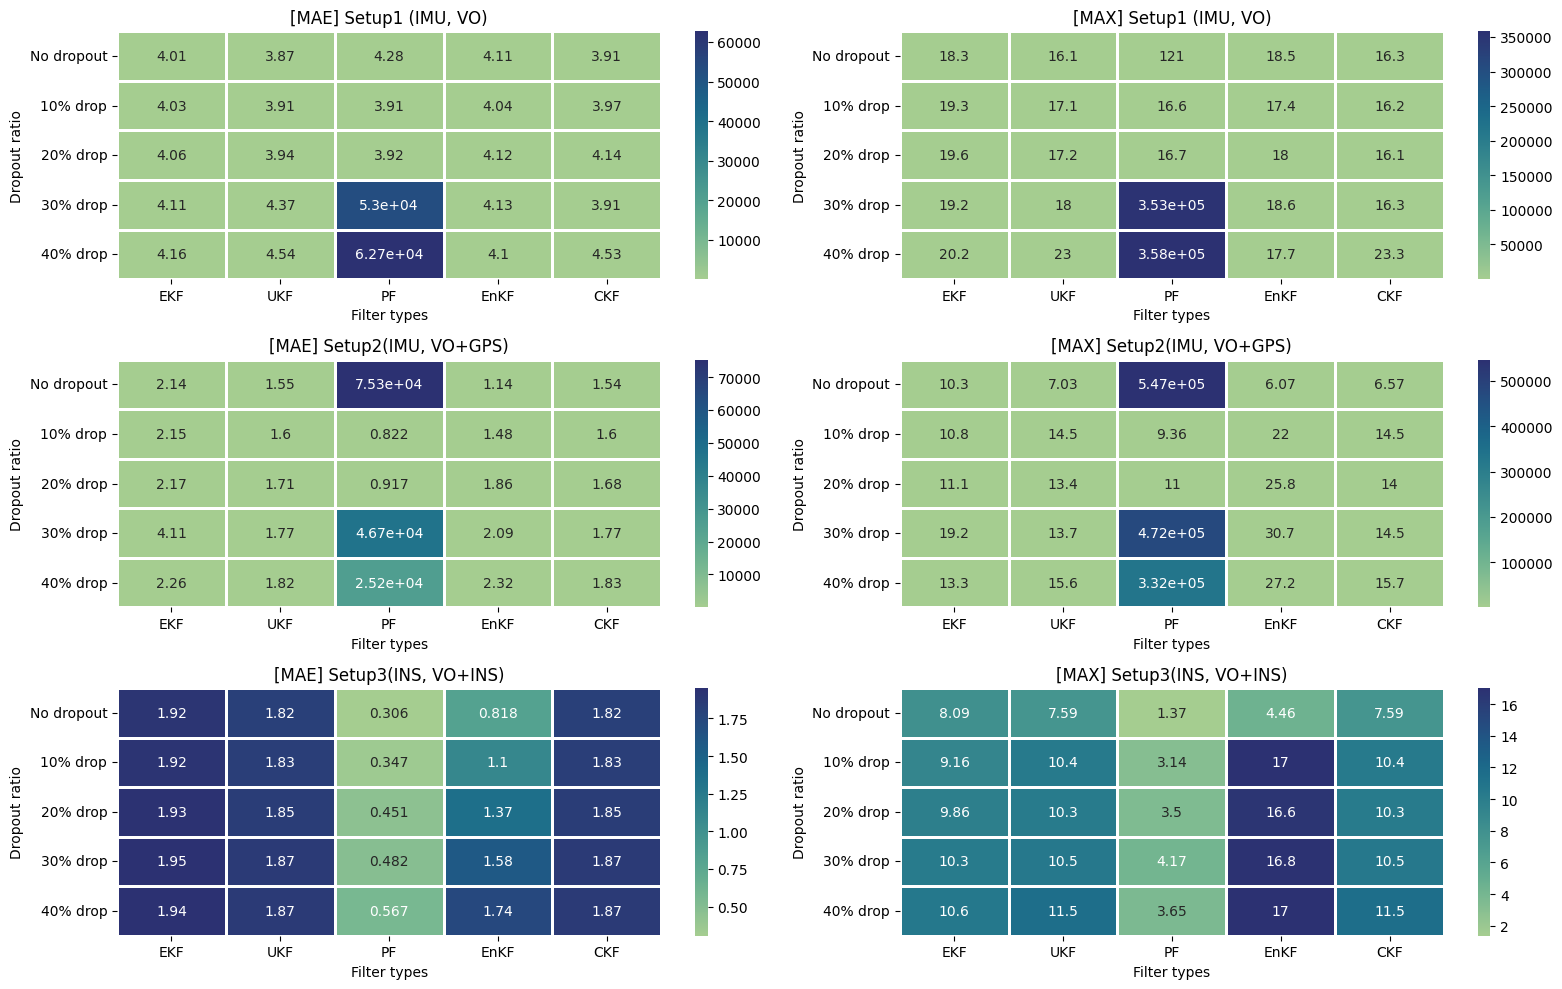

In [53]:
fig, (ax1_, ax2_, ax3_) = plt.subplots(nrows=3, ncols=2, figsize=(16, 10))
ax1, ax2 = ax1_[0], ax1_[1]
ax3, ax4 = ax2_[0], ax2_[1]
ax5, ax6 = ax3_[0], ax3_[1]

sns.heatmap(mae_df["Setup1 (IMU, VO)"],
            ax=ax1,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax1.set_title("[MAE] Setup1 (IMU, VO)")
ax1.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(mae_df["Setup2(IMU, VO+GPS)"],
            ax=ax3,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax3.set_title("[MAE] Setup2(IMU, VO+GPS)")
ax3.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(mae_df["Setup3(INS, VO+INS)"],
            ax=ax5,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax5.set_title("[MAE] Setup3(INS, VO+INS)")
ax5.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(max_df["Setup1 (IMU, VO)"],
            ax=ax2,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax2.set_title("[MAX] Setup1 (IMU, VO)")
ax2.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(max_df["Setup2(IMU, VO+GPS)"],
            ax=ax4,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax4.set_title("[MAX] Setup2(IMU, VO+GPS)")
ax4.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(max_df["Setup3(INS, VO+INS)"],
            ax=ax6,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax6.set_title("[MAX] Setup3(INS, VO+INS)")
ax6.set(xlabel="Filter types", ylabel="Dropout ratio")

fig.tight_layout()

In [54]:
mae_df.to_json(os.path.join(file_export_path, "mae_df.json"))
rmse_df.to_json(os.path.join(file_export_path, "rmse_df.json"))
max_df.to_json(os.path.join(file_export_path, "max_df.json"))